# Figure: Intermediary Matching

This notebook generates figures from **Experiment 4** results.

**Inputs**: `../data/results_4/` (JSON files), `../data/instances/2020-08-27.yaml`

**Outputs**:
- `../figures/matched_heatplot.pdf` — Heatmap of matched intermediaries by cost and deviation potential
- `../figures/intermediary_profit.pdf` — Intermediary profit visualization

In [1]:
import os

In [7]:
os.getcwd()

'/Users/nachatjatusripitak/Desktop/Paper Revision/StablePlatformMatching/notebooks'

In [24]:
import sys
sys.path.insert(0, '../../FactoredPlatformSolver/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from copy import deepcopy


from farmers_intermediaries import Instance
from road_graphs import RoadGraph
import pickle
import pandas as pd
import pricing
from pricing import Optimizer
from datetime import datetime, timedelta
import numpy as np

new_json_files = {}

new_directory = "../results/results_4"

for filename in os.listdir(new_directory):
    if filename.endswith(".json"):
        filepath = os.path.join(new_directory, filename)
        with open(filepath, 'r') as file:
            new_json_files[filename] = json.load(file)

old_json_files = {}

old_directory = "../results_4"

for filename in os.listdir(old_directory):
    if filename.endswith(".json"):
        filepath = os.path.join(old_directory, filename)
        with open(filepath, 'r') as file:
            old_json_files[filename] = json.load(file)

In [25]:
instance_str = "2020-08-27"

graph_data_filename = "../../FactoredPlatformSolver/data/instances/"+instance_str+"_graph.pkl"
Platform = Instance.from_yaml('../../FactoredPlatformSolver/data/instances/'+instance_str+'.yaml')

if not Platform.load_graph_data(graph_data_filename):
    with open("../../FactoredPlatformSolver/data/graph_0-14960_00.pickle", 'rb') as pickle_file:
        G = pickle.load(pickle_file)
    Platform.set_graph(RoadGraph(G))

../../FactoredPlatformSolver/data/instances/2020-08-27_graph.pkl


/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_59437/4106822982.py:8: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(pickle_file)


In [26]:
summ_dict = []
farmer_dict = []
maximum = -np.inf
minimum = np.inf
for name, json_file in old_json_files.items():
    for grid_index, result in enumerate(json_file):
        for int_prioritized in result["cost"]:
            matched = int_prioritized in result["summary_vanilla"]["max_int_welf_sol"]["matched_set"]
            summ_dict.append({
                "epsilon": result["epsilon"][int_prioritized],
                "cost": result["cost"][int_prioritized],
                "status-quo": result["summary_vanilla"]["instance"]["status_quo_quantities"][int_prioritized],
                "power": result["epsilon"][int_prioritized]+result["summary_vanilla"]["instance"]["status_quo_quantities"][int_prioritized],
                "instance_str": result["instance_str"],
                "int_prioritized": int_prioritized,
                "matched": float(matched),
                "profit_max": result["summary_vanilla"]["max_int_welf_sol"]["intermediary_profits"][int_prioritized]/ Platform.USD,
                "profit_min": result["summary_vanilla"]["min_int_welf_sol"]["intermediary_profits"][int_prioritized]/ Platform.USD,
            })            

df = pd.DataFrame(summ_dict)
df = df.query("power <=12")
df["profit_max_after_payment"] = df["profit_max"] + df["cost"]
df["fixed_cost"] = df["cost"] + 800000
df["fixed_cost"] = df["fixed_cost"]/Platform.USD


In [27]:
df.describe()

,epsilon,cost,status-quo,power,matched,profit_max,profit_min,profit_max_after_payment,fixed_cost
count,26425.000000,2.642500e+04,26425.00000,26425.000000,26425.000000,26425.000000,26425.000000,2.642500e+04,26425.000000
mean,2.913759,6.022009e+05,2.29958,5.213339,0.299603,4.783166,2.982509,6.022057e+05,96.703510
std,1.725046,3.078812e+05,2.33273,2.772884,0.458093,14.755460,12.208795,3.078757e+05,21.233188
min,0.000187,-2.113092e+05,0.00000,0.000829,0.000000,0.000000,0.000000,-2.112493e+05,40.599363
25%,1.410734,3.603115e+05,0.00000,3.118407,0.000000,0.000000,0.000000,3.603115e+05,80.021484
50%,2.867137,6.045063e+05,2.00000,5.043975,0.000000,0.000000,0.000000,6.045063e+05,96.862502
75%,4.378334,8.282949e+05,3.70000,7.162334,1.000000,0.000000,0.000000,8.282949e+05,112.296203
max,5.999879,1.700023e+06,10.50000,11.998149,1.000000,166.095056,158.239402,1.700023e+06,172.415394


In [28]:
summ_dict = []
farmer_dict = []
maximum = -np.inf
minimum = np.inf
for name, json_file in new_json_files.items():
    for grid_index, result in enumerate(json_file):
        for int_prioritized in result["cost"]:
            matched = int_prioritized in result["summary_vanilla"]["max_int_welf_sol"]["matched_set"]
            summ_dict.append({
                "epsilon": result["epsilon"][int_prioritized],
                "cost": result["cost"][int_prioritized],
                "status-quo": result["summary_vanilla"]["instance"]["status_quo_quantities"][int_prioritized],
                "power": result["epsilon"][int_prioritized]+result["summary_vanilla"]["instance"]["status_quo_quantities"][int_prioritized],
                "instance_str": result["instance_str"],
                "int_prioritized": int_prioritized,
                "matched": float(matched),
                "profit_max": result["summary_vanilla"]["max_int_welf_sol"]["intermediary_profits"][int_prioritized]/ Platform.USD,
                "profit_min": result["summary_vanilla"]["min_int_welf_sol"]["intermediary_profits"][int_prioritized]/ Platform.USD,
            })            

df = pd.DataFrame(summ_dict)
df = df.query("power <=12")
df["profit_max_after_payment"] = df["profit_max"] + df["cost"]
df["fixed_cost"] = df["cost"] + 800000
df["fixed_cost"] = df["fixed_cost"]/Platform.USD


In [29]:
df.describe()

,epsilon,cost,status-quo,power,matched,profit_max,profit_min,profit_max_after_payment,fixed_cost
count,26564.000000,2.656400e+04,26564.000000,26564.000000,26564.000000,26564.000000,26564.000000,2.656400e+04,26564.000000
mean,2.914360,6.023460e+05,2.300474,5.214834,0.299654,4.761569,2.994273,6.023508e+05,96.713518
std,1.725182,3.079344e+05,2.333007,2.772677,0.458115,14.736162,12.247217,3.079289e+05,21.236857
min,0.000187,-2.113092e+05,0.000000,0.000829,0.000000,0.000000,0.000000,-2.112493e+05,40.599363
25%,1.410783,3.604484e+05,0.000000,3.120554,0.000000,0.000000,0.000000,3.604484e+05,80.030922
50%,2.868371,6.045551e+05,2.000000,5.046822,0.000000,0.000000,0.000000,6.045551e+05,96.865867
75%,4.380500,8.284673e+05,3.700000,7.163458,1.000000,0.000000,0.000000,8.284673e+05,112.308089
max,5.999879,1.700023e+06,10.500000,11.998149,1.000000,166.095056,158.239402,1.700023e+06,172.415394


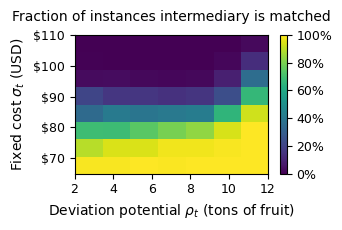

In [6]:
from matplotlib.ticker import FuncFormatter

# Define a formatter function for the y-axis
def currency_formatter(x, pos):
    return f'${x:.0f}'


import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Create bins for power and cost
power_bins = np.linspace(2, 12, 7)
cost_bins = np.linspace(65, 110, 7)

# Assign bin indices
df['power_bin'] = np.digitize(df['power'], power_bins) - 1
df['cost_bin'] = np.digitize(df['fixed_cost'], cost_bins) - 1

# Compute probability that matched = 1 in each (power, cost) bin
heatmap = df.groupby(['power_bin', 'cost_bin'])['matched'].mean().unstack() * 100  # Convert to percentage

# Plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap.T, origin='lower', aspect='auto',
    extent=[power_bins[0], power_bins[-1], cost_bins[0], cost_bins[-1]],
    cmap='viridis'
)
cbar = plt.colorbar()
# Format colorbar ticks as percentages
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
#plt.xticks(ticks=np.arange(len(power_bins)), labels=[f"{p:.1f}" for p in power_bins], rotation=45)
# Apply the formatter to the y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
plt.title(r'Fraction of instances intermediary is matched', pad=10)
plt.tight_layout()
plt.savefig("../figures/matched_heatplot.png", bbox_inches='tight', dpi=300)  # INFORMS-compliant
plt.show()


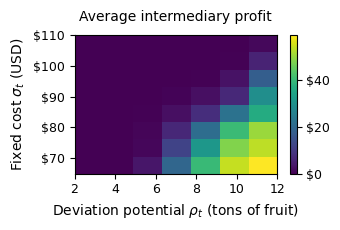

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Create bins for power and cost
power_bins = np.linspace(2, 12, 7)
cost_bins = np.linspace(65, 110, 7)

# Assign bin indices
df['power_bin'] = np.digitize(df['power'], power_bins) - 1
df['cost_bin'] = np.digitize(df['fixed_cost'], cost_bins) - 1

heatmap = df.groupby(['power_bin', 'cost_bin'])['profit_max'].mean().unstack()

# Plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap.T, origin='lower', aspect='auto',
    extent=[power_bins[0], power_bins[-1], cost_bins[0], cost_bins[-1]],
    cmap='viridis'
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
cbar = plt.colorbar(label='')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
#plt.xticks(ticks=np.arange(len(power_bins)), labels=[f"{p:.1f}" for p in power_bins], rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.title(r"Average intermediary profit", pad=10)
plt.tight_layout()

plt.savefig("../figures/intermediary_profit.png", bbox_inches='tight', dpi=300)  # INFORMS-compliant
plt.show()